# Figure 2 panel assembly

Rebuild assembled panels directly from cached RDS files in `figure_data/`.

## Setup

Each panel is rebuilt from its cached RDS in `figure_data/`. Output:
`figure_data/Figure_2.pdf`.

Canvas: 17 x 10 in. Slot sizes follow the requested area ordering
**2a > 2d > 2c > 2b** while preserving readable scale for the
data-bearing panels:

```
+----------+----------+--------------+
|          |          |              |
|          |   2b     |     2c       |
|   2a     |          |              |
|          +----------+--------------+
|          |                         |
|          |   2d                    |
|          |                         |
+----------+-------------------------+
```

In [1]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(tibble)
  library(ggplot2)
  library(scales)
  library(cowplot)
  library(grid)
  library(ComplexHeatmap)
  library(circlize)
})

figure_data_dir <- normalizePath("figure_data", mustWork = TRUE)
rds <- function(name) file.path(figure_data_dir, name)

base_theme <- theme_bw(base_size = 15) +
  theme(text = element_text(family = "sans", color = "black"),
        panel.grid.minor = element_blank(),
        strip.background = element_blank())

white_bg <- theme(plot.background = element_rect(fill = "white", colour = NA),
                  plot.margin = margin(2, 2, 2, 2))
label_panel <- function(p, label) {
  ggdraw(p) + draw_label(label, x = 0.006, y = 0.992, hjust = 0, vjust = 1,
                         fontface = "bold", size = 18) + white_bg
}
blank_panel <- function(label) label_panel(ggdraw(), label)
qtl_text <- function(x) gsub("gpQTL", "glycoQTL", x, fixed = TRUE)


In [2]:
# Panel b: loci counts
loci <- readRDS(rds("Figure_2_num_xQTL_loci_single_context.rds"))
cat_levels <- c("pip sum >= 0.95", "1-2", "3-6", "7-10", ">10")
panel_group_order <- c("Cell-type eQTL", "Bulk eQTL", "sQTL", "pQTL/glycoQTL")

assign_panel_group <- function(r) case_when(
  grepl("sQTL", r) ~ "sQTL",
  grepl("gpQTL|pQTL", r) ~ "pQTL/glycoQTL",
  grepl("monocyte|Mac|Ast|Exc|Inh|Mic|OPC|Oli", r) ~ "Cell-type eQTL",
  TRUE ~ "Bulk eQTL"
)
assign_panel_subgroup <- function(r) case_when(
  grepl("Ast|Exc|Inh|Mic|OPC|Oli", r) ~ "snuc eQTL",
  grepl("monocyte|Mac", r) ~ "immune bulk eQTL",
  grepl("gpQTL", r) ~ "glycoQTL",
  grepl("pQTL", r) ~ "pQTL",
  TRUE ~ ""
)
strip_qtl <- function(x) trimws(gsub("\\s+(eQTL|sQTL|pQTL|gpQTL|glycoQTL)\\b", "", qtl_text(x), perl = TRUE))

prep_loci <- function(df, group_label, cat_col) {
  df %>%
    filter(!grepl("_adjusted", resource)) %>%
    mutate(group = factor(group_label, levels = c("Detectable", "Mappable")),
           display_resource = strip_qtl(gsub("_", " ", display_resource)),
           display_resource = recode(display_resource, "Klein DLPFC unadjusted" = "ROSMAP DLPFC glyco", "Bennett DLPFC" = "ROSMAP DLPFC", "Knight brain" = "Knight"),
           display_resource = recode(display_resource, "MetaBrain Basalganglia" = "MetaBrain BG",
                                     "MetaBrain Hippocampus" = "MetaBrain Hippo",
                                     "MetaBrain Spinalcord" = "MetaBrain Spinal"),
           n_category = .data[[cat_col]]) %>%
    group_by(group, resource, display_resource, n_category) %>%
    summarise(gene_count = sum(gene_count, na.rm = TRUE), .groups = "drop") %>%
    filter(gene_count > 0, !is.na(n_category)) %>%
    group_by(group, resource, display_resource) %>%
    mutate(total_count = sum(gene_count)) %>%
    ungroup() %>%
    mutate(n_category = factor(n_category, levels = cat_levels),
           panel_group = factor(assign_panel_group(resource), levels = panel_group_order),
           panel_subgroup = factor(assign_panel_subgroup(resource),
                                   levels = c("snuc eQTL", "immune bulk eQTL", "pQTL", "glycoQTL", "")))
}

plot_data <- bind_rows(
  prep_loci(loci$data$detectable_v2, "Detectable", "n_detectable_category"),
  prep_loci(loci$data$mappable_v2, "Mappable", "n_mappable_category")
) %>%
  filter(!(panel_group == "Cell-type eQTL" & panel_subgroup == "snuc eQTL") |
           grepl("DeJager", resource))

cs_totals_long <- loci$data$cs_totals %>%
  filter(!grepl("_adjusted", resource)) %>%
  pivot_longer(c(total_detectable_cs, total_mappable_cs),
               names_to = "group", values_to = "total_cs") %>%
  mutate(group = factor(ifelse(group == "total_detectable_cs", "Detectable", "Mappable"),
                        levels = c("Detectable", "Mappable"))) %>%
  select(resource, group, total_cs)

resource_order <- plot_data %>%
  distinct(group, resource, display_resource, panel_group, panel_subgroup, total_count) %>%
  group_by(resource, display_resource, panel_group, panel_subgroup) %>%
  summarise(max_total = max(total_count), .groups = "drop") %>%
  arrange(panel_group, panel_subgroup, desc(max_total), display_resource) %>%
  mutate(y_global = -row_number() * 0.50)

seg <- plot_data %>%
  left_join(resource_order %>% select(resource, y_global), by = "resource") %>%
  arrange(y_global, group, n_category) %>%
  group_by(group, resource) %>%
  mutate(xmin = lag(cumsum(gene_count), default = 0),
         xmax = cumsum(gene_count),
         y_offset = ifelse(group == "Detectable", 0.10, -0.10),
         ymin = y_global + y_offset - 0.085,
         ymax = y_global + y_offset + 0.085,
         group_category = interaction(group, n_category, sep = ": ", drop = TRUE)) %>%
  ungroup()

bar_labels <- seg %>%
  distinct(group, resource, panel_group, y_global, y_offset, total_count) %>%
  left_join(cs_totals_long, by = c("resource", "group")) %>%
  mutate(y = y_global + y_offset, label = format(total_cs, big.mark = ",", trim = TRUE))
x_limit <- max(bar_labels$total_count, na.rm = TRUE) * 1.16
fill_pal <- c(setNames(c("#F2F2F2", "#C6DBEF", "#6BAED6", "#2171B5", "#08306B"), paste0("Detectable: ", cat_levels)),
              setNames(c("#F2F2F2", "#FEE0D2", "#FC9272", "#DE2D26", "#A50F15"), paste0("Mappable: ", cat_levels)))
text_pal <- c(Detectable = "#08306B", Mappable = "#A50F15")

p_b <- ggplot(seg) +
  geom_rect(aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax, fill = group_category),
            color = "grey25", linewidth = 0.13) +
  geom_text(data = bar_labels, aes(x = total_count + x_limit * 0.01, y = y, label = label, color = group),
            inherit.aes = FALSE, size = 3.0, fontface = "bold", hjust = 0) +
  facet_grid(rows = vars(panel_group), scales = "free_y", space = "free_y") +
  scale_fill_manual(values = fill_pal, guide = "none") +
  scale_color_manual(values = text_pal, guide = "none") +
  scale_x_continuous(breaks = c(0, 5000, 10000), labels = label_number(big.mark = ","),
                     limits = c(0, x_limit), expand = expansion(mult = c(0, 0))) +
  scale_y_continuous(breaks = resource_order$y_global, labels = resource_order$display_resource,
                     expand = expansion(add = c(0.1, 0.1))) +
  labs(x = "Number of loci", y = NULL) +
  coord_cartesian(clip = "off") + base_theme +
  theme(axis.title.x = element_text(size = 12, face = "bold", margin = margin(t = 4)),
        axis.text.x = element_text(size = 10),
        axis.text.y = element_text(size = 11, face = "bold"),
        strip.text.y.right = element_text(size = 11, face = "bold", angle = 270),
        panel.grid.major.y = element_blank(),
        legend.position = "none",
        plot.margin = margin(2, 22, 2, 2))

In [3]:
# Panel c: distance summary
dist <- readRDS(rds("Figure_2_single_context_cs_distance.rds"))
distance_levels <- c("<10Kb", "10Kb~50Kb", "50Kb~100Kb", "100Kb~1Mb", ">1Mb")
modality_colors <- c("Cell-type eQTL" = "#2F6FB0", "Bulk eQTL" = "#7AA6D9",
                     "sQTL" = "#B54852", "pQTL" = "#D9896C", "glycoQTL" = "#8B6FAE")
assign_modality <- function(r) case_when(
  grepl("sQTL", r) ~ "sQTL",
  grepl("gpQTL", r) ~ "glycoQTL",
  grepl("pQTL", r) ~ "pQTL",
  grepl("monocyte|Mac|Ast|Exc|Inh|Mic|OPC|Oli", r) ~ "Cell-type eQTL",
  TRUE ~ "Bulk eQTL"
)
dist_df <- dist$data$singlecontext_top_loci_table_integrated_distance_filtered_category %>%
  mutate(distance_category = factor(as.character(distance_category), levels = distance_levels),
         modality_group = factor(assign_modality(resource), levels = names(modality_colors)))
interval_metrics <- dist_df %>%
  group_by(resource, modality_group) %>%
  summarise(`<= 100 kb` = sum(frequency[distance_category %in% distance_levels[1:3]], na.rm = TRUE),
            `>= 1 Mb` = sum(frequency[distance_category == ">1Mb"], na.rm = TRUE),
            .groups = "drop") %>%
  pivot_longer(c(`<= 100 kb`, `>= 1 Mb`), names_to = "metric", values_to = "fraction") %>%
  mutate(metric = factor(metric, levels = c("<= 100 kb", ">= 1 Mb")))
p_c <- ggplot(interval_metrics, aes(modality_group, fraction, fill = modality_group, color = modality_group)) +
  geom_boxplot(width = 0.58, alpha = 0.35, outlier.shape = NA, linewidth = 0.5) +
  geom_point(position = position_jitter(width = 0.11, height = 0, seed = 1), size = 1.3, alpha = 0.65) +
  facet_wrap(~ metric, nrow = 1) +
  scale_y_continuous(labels = percent_format(accuracy = 1), limits = c(0, 1), expand = expansion(mult = c(0.01, 0.04))) +
  scale_fill_manual(values = modality_colors, guide = "none") +
  scale_color_manual(values = modality_colors, guide = "none") +
  labs(x = NULL, y = "Fraction of events") + base_theme +
  theme(axis.text.x = element_text(size = 10, angle = 60, hjust = 1, vjust = 1, face = "bold"),
        axis.text.y = element_text(size = 11),
        axis.title.y = element_text(size = 12, face = "bold", margin = margin(r = 4)),
        strip.text = element_text(size = 11, face = "bold"),
        panel.grid.major.x = element_blank(),
        plot.margin = margin(2, 2, 2, 2))

In [4]:
# Panels e/f: heatmaps from RDS
short_trait <- function(x) {
  dplyr::recode(x,
    "AD_Bellenguez_EADB_hg38_sorted" = "Bell. EADB",
    "AD_Bellenguez_buildGRCh38" = "Bell. GRCh38",
    "AD_Kunkle_etal_Stage1_results_hg38.sorted.munged" = "Kunkle",
    "AD_Wightman_Excluding23andMe" = "Wight. -23",
    "AD_Wightman_ExcludingUKB23andMe" = "Wight. -UKB/23",
    "AD_Wightman_full_2021" = "Wight. full",
    "PASS_Alzheimers_Jansen2019" = "Jansen",
    "UKB.Mono.BOLT" = "Mono", "UKB.Lym.BOLT" = "Lym", "UKB.Neutro.BOLT" = "Neutro",
    "PASS_Multiple_sclerosis" = "MS", "PASS_IBD_deLange2017" = "IBD",
    "PASS_CD_deLange2017" = "CD", "PASS_Rheumatoid_Arthritis" = "RA",
    .default = gsub("_", " ", x))
}
star_from_z <- function(z) ifelse(is.na(z), "", ifelse(abs(z) > 4.4, "***", ifelse(abs(z) > 3.3, "**", ifelse(abs(z) > 1.96, "*", ""))))

# Force ComplexHeatmap to use the same sans family as ggplot panels
ht_opt$message <- FALSE
ht_opt$ROW_ANNO_PADDING       <- unit(2, "mm")
ht_opt$COLUMN_ANNO_PADDING    <- unit(2, "mm")

# ------- Panel f: sLDSC tau heatmap --------------------------------------
sld <- readRDS(rds("Figure_2_sLDSC_FM_all_methods.rds"))
landmark <- tibble::tribble(
  ~trait, ~category,
  "AD_Bellenguez_EADB_hg38_sorted", "AD", "AD_Bellenguez_buildGRCh38", "AD",
  "AD_Kunkle_etal_Stage1_results_hg38.sorted.munged", "AD", "AD_Wightman_Excluding23andMe", "AD",
  "AD_Wightman_ExcludingUKB23andMe", "AD", "AD_Wightman_full_2021", "AD",
  "PASS_Alzheimers_Jansen2019", "AD", "UKB.Mono.BOLT", "Blood", "UKB.Lym.BOLT", "Blood",
  "UKB.Neutro.BOLT", "Blood", "PASS_Multiple_sclerosis", "Autoimmune",
  "PASS_IBD_deLange2017", "Autoimmune", "PASS_CD_deLange2017", "Autoimmune",
  "PASS_Rheumatoid_Arthritis", "Autoimmune")

loci_univ <- as_tibble(sld$data$loci_df) %>%
  filter(method == "univariate", grepl("^ROSMAP_", study), !grepl("_adjusted|_trans_|_(DeJager|Kellis)$", study))
tau_tbl <- as_tibble(sld$data$tau_df) %>%
  mutate(trait = sub("\\.parquet$", "", trait)) %>%
  filter(study %in% loci_univ$study, trait %in% landmark$trait) %>%
  distinct(study, trait, .keep_all = TRUE)

mat_tau <- tau_tbl %>% select(study, trait, tau_star) %>%
  pivot_wider(names_from = trait, values_from = tau_star) %>% column_to_rownames("study") %>% as.matrix()
mat_z <- tau_tbl %>% select(study, trait, tau_z) %>%
  pivot_wider(names_from = trait, values_from = tau_z) %>% column_to_rownames("study") %>% as.matrix()
missing_cols <- setdiff(landmark$trait, colnames(mat_tau))
if (length(missing_cols)) {
  pad <- matrix(NA_real_, nrow = nrow(mat_tau), ncol = length(missing_cols), dimnames = list(rownames(mat_tau), missing_cols))
  mat_tau <- cbind(mat_tau, pad); mat_z <- cbind(mat_z, pad)
}
mat_tau <- mat_tau[, landmark$trait, drop = FALSE]; mat_z <- mat_z[rownames(mat_tau), landmark$trait, drop = FALSE]
# Row groups for ht_f (parallel to panel b's facet logic)
f_row_levels <- c("Cell-type eQTL", "Bulk eQTL", "sQTL", "pQTL/glycoQTL", "Other")
assign_f_row_group <- function(s) {
  dplyr::case_when(
    grepl("^ROSMAP_sQTL_", s) ~ "sQTL",
    grepl("^ROSMAP_gpQTL_|^ROSMAP_pQTL_", s) ~ "pQTL/glycoQTL",
    grepl("^ROSMAP_eQTL_(monocyte|Mac|Ast|Exc|Inh|Mic|OPC|Oli)", s) ~ "Cell-type eQTL",
    grepl("^ROSMAP_eQTL_", s) ~ "Bulk eQTL",
    TRUE ~ "Other"
  )
}
row_group_f <- factor(assign_f_row_group(rownames(mat_tau)), levels = f_row_levels)
# Within pQTL/glycoQTL group: force pQTL rows before glycoQTL rows
sub_order_f <- dplyr::case_when(
  grepl("^ROSMAP_pQTL_", rownames(mat_tau)) ~ 1L,
  grepl("^ROSMAP_gpQTL_", rownames(mat_tau)) ~ 2L,
  grepl("^ROSMAP_eQTL_Mic_mega", rownames(mat_tau)) ~ -1L,
  grepl("^ROSMAP_eQTL_monocyte", rownames(mat_tau)) ~ 10L,
  TRUE ~ 5L
)
row_ord <- order(as.integer(row_group_f), sub_order_f, rownames(mat_tau))
mat_tau <- mat_tau[row_ord,,drop=FALSE]; mat_z <- mat_z[row_ord,,drop=FALSE]
row_group_f <- row_group_f[row_ord]
# Panel f row labels: align with panel b naming (CUIMC1 / ROSMAP prefixes)
row_lab_f <- function(x) {
  dplyr::case_when(
    grepl("^ROSMAP_eQTL_monocyte", x) ~ "ROSMAP monocyte",
    grepl("^ROSMAP_eQTL_", x) ~ paste0("CUIMC1 ",
      gsub("Macrophage", "Mac", gsub("_mega", "", sub("^ROSMAP_eQTL_", "", x)))),
    grepl("^ROSMAP_sQTL_", x) ~ paste0("ROSMAP ", sub("^ROSMAP_sQTL_", "", x)),
    grepl("^ROSMAP_pQTL_", x) ~ "ROSMAP DLPFC pQTL",
    grepl("^ROSMAP_gpQTL_", x) ~ "ROSMAP DLPFC glycoQTL",
    grepl("^ROSMAP_haQTL_", x) ~ "ROSMAP haQTL",
    grepl("^ROSMAP_mQTL_", x) ~ "ROSMAP mQTL", TRUE ~ x)
}
col_anno <- landmark %>% mutate(category = factor(category, levels = c("AD", "Blood", "Autoimmune")))
cat_pal <- c(AD = "#0072B2", Blood = "#009E73", Autoimmune = "#D55E00")
tau_col <- colorRamp2(c(-2, -1, 0, 0.5, 1, 2), c("#053061", "#2166AC", "#FFFFFF", "#F4A582", "#D6604D", "#67001F"))
ht_f <- Heatmap(mat_tau, name = "tau", col = tau_col, na_col = "grey90",
  width  = unit(ncol(mat_tau) * 6.0, "mm"),
  height = unit(nrow(mat_tau) * 5.2, "mm"),
  cluster_rows = FALSE, cluster_columns = FALSE,
  row_split = row_group_f, cluster_row_slices = FALSE,
  column_split = col_anno$category, cluster_column_slices = FALSE,
  row_title = c("Cell-type eQTL", "Bulk eQTL", "sQTL", "", ""),
  row_title_gp = gpar(fontfamily = "sans", fontsize = 10, fontface = "bold"),
  row_title_rot = 90, row_gap = unit(2, "mm"),
  top_annotation = HeatmapAnnotation(
    Bar = anno_block(
      gp = gpar(fill = cat_pal[levels(col_anno$category)], col = NA),
      height = unit(5, "mm"),
      labels = levels(col_anno$category),
      labels_gp = gpar(fontfamily = "sans", fontsize = 9, col = "white", fontface = "bold")),
    show_annotation_name = FALSE),
  row_labels = row_lab_f(rownames(mat_tau)), column_labels = short_trait(colnames(mat_tau)),
  row_names_gp = gpar(fontfamily = "sans", fontsize = 11), column_names_gp = gpar(fontfamily = "sans", fontsize = 11),
  column_names_rot = 60, column_names_max_height = unit(2.8, "cm"),
  column_title = NULL,
  column_gap = unit(1.8, "mm"),
  rect_gp = gpar(col = "white", lwd = 0.5), border = FALSE,
  heatmap_legend_param = list(title = "tau",
    title_gp = gpar(fontfamily = "sans", fontsize = 11, fontface = "bold"),
    labels_gp = gpar(fontfamily = "sans", fontsize = 10),
    at = c(-2, -1, 0, 1, 2), legend_height = unit(3.0, "cm")),
  cell_fun = function(j, i, x, y, w, h, fill) {
    s <- star_from_z(mat_z[i, j])
    if (nzchar(s)) grid.text(s, x, y, gp = gpar(fontfamily = "sans", fontsize = 10, fontface = "bold"))
  })
p_f <- grid.grabExpr(draw(ht_f,
  heatmap_legend_side = "right", annotation_legend_side = "right",
  merge_legend = TRUE, padding = unit(c(1, 1, 1, 1), "mm")))

# ------- Panel e: EOO FM vs LR side-by-side ComplexHeatmap ---------------
eoo          <- readRDS(rds("Figure_2_EOO_FM_vs_LR_comparison.rds"))
mat_fm       <- eoo$data$mat_fm
mat_lr       <- eoo$data$mat_lr
cat_order_df <- eoo$data$cat_order_df
study_info   <- eoo$data$study_info
sc_order     <- eoo$data$sc_order

col_fun_eoo <- colorRamp2(
  c(-2, 0, 1, 2, 3, 4, 6),
  c("#2166AC", "#FFFFFF", "#FDDBC7", "#F4A582", "#D6604D", "#B2182B", "#67001F"))
qtl_levels  <- c("Cell-type eQTL", "Bulk eQTL", "pQTL")
qtl_internal_to_pretty <- c("snuc-eQTL" = "Cell-type eQTL", "eQTL" = "Bulk eQTL", "pQTL" = "pQTL")
qtl_pal_eoo <- setNames(c("#C44E52", "#4C72B0", "#8172B2"), qtl_levels)

col_split_eoo <- factor(
  unname(qtl_internal_to_pretty[setNames(study_info$QTL_type, study_info$study_norm)[colnames(mat_fm)]]),
  levels = qtl_levels)

# Concise super-category labels for row splits; "Other" becomes blank
sc_short <- c("Molecular_QTL" = "Mol QTL",
              "CellType_specific" = "Cell type",
              "Epigenetic_Regulation" = "Epigen.",
              "Conservation" = "Cons.",
              "Other" = " ")
row_split_eoo <- factor(
  setNames(as.character(cat_order_df$Super_category),
           cat_order_df$Category)[rownames(mat_fm)],
  levels = sc_order)
levels(row_split_eoo) <- unname(sc_short[levels(row_split_eoo)])

clean_eoo <- function(x) {
  x <- gsub("_(eQTL|sQTL|pQTL)$", "", x, perl = TRUE)
  x <- sub("^(AC|DLPFC|PCC)_DeJager$", "CUIMC1 \\1", x)
  x <- sub("^BM_(\\d+)_MSBB$", "MSBB BM\\1", x)
  x <- sub("^(Ast|Exc|Inh|Mic|OPC|Oli)_mega$", "CUIMC1 \\1", x)
  x <- sub("^DLPFC_Bennett$", "ROSMAP DLPFC", x)
  x <- gsub("_", " ", x, fixed = TRUE)
  trimws(x)
}
row_clean_eoo <- function(x) {
  x <- gsub("CellType_", "", x, fixed = TRUE)
  x <- gsub("_", " ", x, fixed = TRUE)
  dplyr::recode(x,
    "Microglia Myeloid" = "Microglia/Myeloid",
    "OtherNonNeural" = "Other non-neural",
    "Other Functional Annotations" = "Other annotations",
    "Epigenetic Histone Modifications" = "Histone mods",
    "Transcription Factor Footprints" = "TF footprints",
    "Chromatin Interaction Loops" = "Chromatin loops",
    "Chromatin Accessibility" = "Chromatin access.",
    "Enhancer SuperEnhancer" = "Enh./Super-Enh.",
    .default = x)
}
make_eoo_top <- function() HeatmapAnnotation(
  QTL = anno_block(
    gp = gpar(fill = qtl_pal_eoo[qtl_levels], col = NA),
    height = unit(3.2, "mm"),
    labels = qtl_levels,
    labels_gp = gpar(fontfamily = "sans", fontsize = 10, col = "white", fontface = "bold")),
  show_annotation_name = FALSE)

nr_e <- nrow(mat_fm); nc_e <- ncol(mat_fm)
ht_fm_e <- Heatmap(
  mat_fm, name = "log2_Enrichment", col = col_fun_eoo, na_col = "grey90",
  width  = unit(nc_e * 4.8, "mm"),
  height = unit(nr_e * 4.2, "mm"),
  cluster_rows = FALSE, cluster_columns = FALSE,
  row_split = row_split_eoo, column_split = col_split_eoo,
  cluster_row_slices = FALSE, cluster_column_slices = FALSE,
  top_annotation = make_eoo_top(),
  column_title = "Fine-mapped (univariate)",
  column_title_gp = gpar(fontfamily = "sans", fontsize = 12, fontface = "bold"),
  row_title_gp  = gpar(fontfamily = "sans", fontsize = 11, fontface = "bold"),
  row_title_rot = 90,
  show_row_names = FALSE,
  show_column_names = TRUE,
  column_labels = clean_eoo(colnames(mat_fm)),
  column_names_gp = gpar(fontfamily = "sans", fontsize = 11),
  column_names_rot = 60, column_names_max_height = unit(3.0, "cm"),
  row_gap = unit(1.2, "mm"), column_gap = unit(1.8, "mm"),
  rect_gp = gpar(col = "white", lwd = 0.5), border = FALSE,
  heatmap_legend_param = list(
    title = "log2 Enrichment",
    title_gp = gpar(fontfamily = "sans", fontsize = 11, fontface = "bold"),
    labels_gp = gpar(fontfamily = "sans", fontsize = 10),
    at = c(-2, 0, 2, 4, 6),
    legend_height = unit(3.4, "cm"), grid_width = unit(4.5, "mm"))
)
ht_lr_e <- Heatmap(
  mat_lr, name = "LR_log2", col = col_fun_eoo, na_col = "grey90",
  width  = unit(nc_e * 4.8, "mm"),
  height = unit(nr_e * 4.2, "mm"),
  cluster_rows = FALSE, cluster_columns = FALSE,
  row_split = row_split_eoo, column_split = col_split_eoo,
  cluster_row_slices = FALSE, cluster_column_slices = FALSE,
  top_annotation = make_eoo_top(),
  column_title = "Linear Regression",
  column_title_gp = gpar(fontfamily = "sans", fontsize = 12, fontface = "bold"),
  row_title_gp  = gpar(fontfamily = "sans", fontsize = 0),
  show_row_names = TRUE,
  row_labels = row_clean_eoo(rownames(mat_lr)),
  row_names_side = "right",
  row_names_gp   = gpar(fontfamily = "sans", fontsize = 11),
  show_column_names = TRUE,
  column_labels = clean_eoo(colnames(mat_lr)),
  column_names_gp = gpar(fontfamily = "sans", fontsize = 11),
  column_names_rot = 60, column_names_max_height = unit(3.0, "cm"),
  row_gap = unit(1.2, "mm"), column_gap = unit(1.8, "mm"),
  rect_gp = gpar(col = "white", lwd = 0.5), border = FALSE,
  show_heatmap_legend = FALSE
)
p_e <- grid.grabExpr(draw(ht_fm_e + ht_lr_e, ht_gap = unit(4, "mm"),
  heatmap_legend_side = "right", annotation_legend_side = "right",
  merge_legend = TRUE, padding = unit(c(2, 2, 2, 5), "mm")))

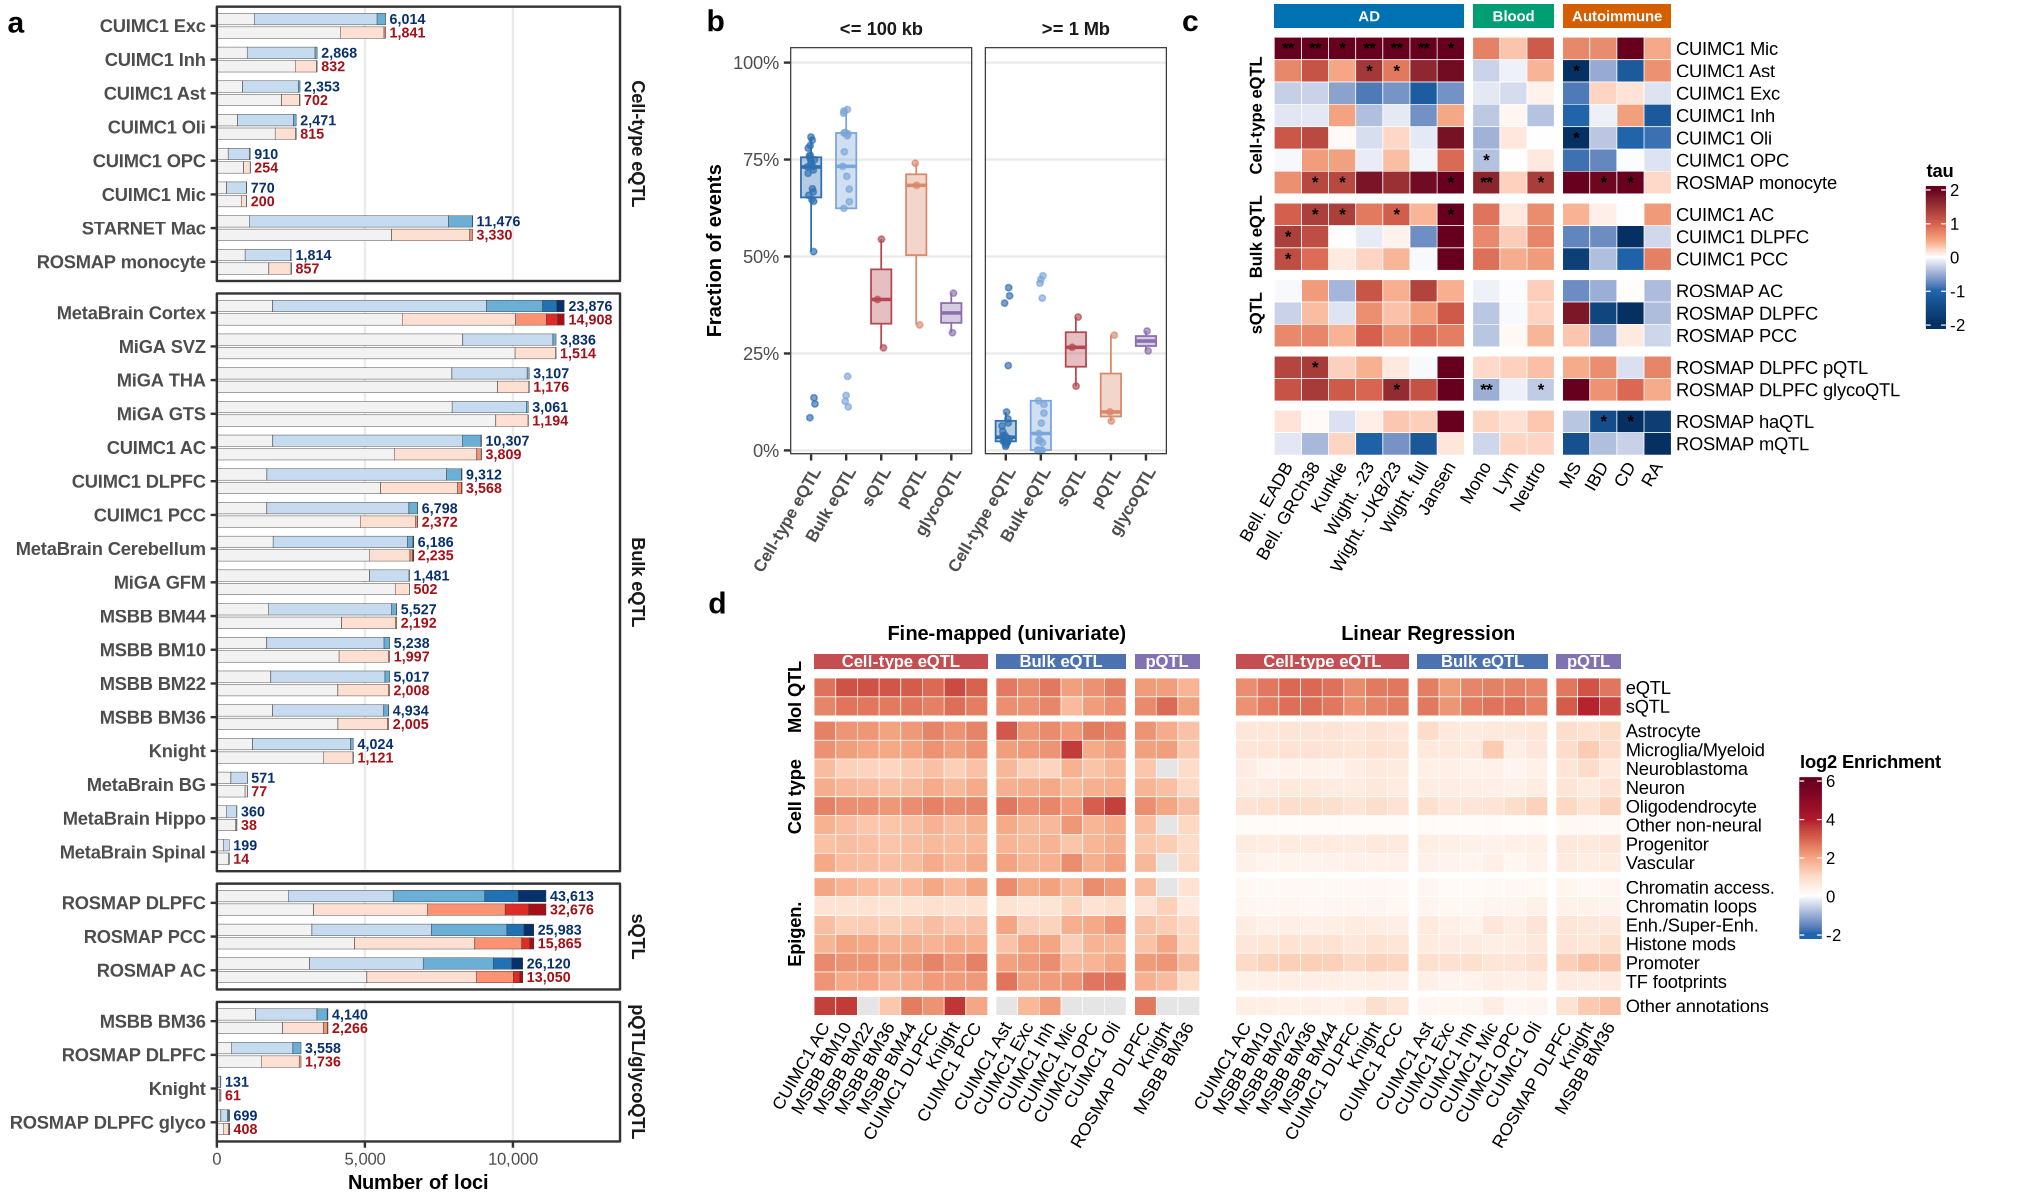

In [5]:
panel_a <- label_panel(p_b, "a")
panel_b <- label_panel(p_c, "b")
panel_c <- label_panel(ggdraw() + draw_grob(p_f), "c")
panel_d <- label_panel(ggdraw() + draw_grob(p_e), "d")

right_top   <- plot_grid(panel_b, panel_c, ncol = 2,
                         rel_widths = c(0.85, 1.55), align = "h")
right_block <- plot_grid(right_top, panel_d, ncol = 1,
                         rel_heights = c(1.0, 1.05), align = "v")
fig2 <- plot_grid(panel_a, right_block, ncol = 2,
                  rel_widths = c(0.82, 1.58), align = "h") +
  theme(plot.background = element_rect(fill = "white", colour = NA))

options(repr.plot.width = 17, repr.plot.height = 10)
fig2

In [6]:
out_pdf <- file.path(figure_data_dir, "Figure_2.pdf")
out_png <- file.path(figure_data_dir, "Figure_2.png")
ggsave(out_pdf, fig2, width = 17, height = 10, device = cairo_pdf, bg = "white", limitsize = FALSE)
ggsave(out_png, fig2, width = 17, height = 10, dpi = 180, bg = "white", limitsize = FALSE)
message("Saved: ", out_pdf)
message("Saved: ", out_png)

Saved: /mnt/lustre/lab/gwang/users/rf2872/Work/codes/xqtl-paper/main_text/2_single_context_cis/figure_data/Figure_2.pdf

Saved: /mnt/lustre/lab/gwang/users/rf2872/Work/codes/xqtl-paper/main_text/2_single_context_cis/figure_data/Figure_2.png

